# Adaptive-length rejuvenation — stop MCMC by decorrelation, not a fixed `n_mcmc`

This notebook exercises the **adaptive rejuvenation** path added to `creativity_measure/smc.py`
(`smc_sample(..., n_mcmc=None)`), on the *same* Swiss-Roll-with-a-hole squared-IEM testbed as
[`normalized_squared_iem_tilt.ipynb`](normalized_squared_iem_tilt.ipynb).

**The idea.** After tempering + resampling, the particle cloud *already* approximates $\pi_\beta$;
rejuvenation's only job is to **undo the duplication `_systematic_resample` just created** — restore
diversity. So "converged" means *"the resampled duplicates have decorrelated"*, not "the chain reached
stationarity". Instead of guessing `n_mcmc`, each tempering level now sweeps until:

- **primary:** the kernel's geometry-aware `decorrelation` drops below a threshold —
  pCN uses the latent-$z$ autocorrelation; `IndependenceKernel` uses the fraction of particles still
  identical to their resampled parent; **or**
- **secondary (early-exit):** the weight-aware mean/std of $f$ plateaus,

bounded below by `min_n_mcmc` and above by the `MAX_N_MCMC` cap. The per-level effort is returned in
`SMCResult.n_mcmc_history`.

**What we check here:** (1) adaptive ≈ hand-tuned fixed on quality, (2) the effort profile concentrates
sweeps on the hard off-manifold levels, (3) the `decorrelation` metric behaves, and (4) the
`decorr_threshold` knob trades sweeps against mixing.

## Setup — Swiss Roll with a hole, squared-IEM tilt $f_{2}$

Reused verbatim from the reference notebook: base density $p$ (24-component GMM fit to a Swiss roll with a
wrap removed), the squared global-IEM distance, the normalized reward $f_{2} = E[D^2] / E_{\text{pair}}[D^2]$,
and the deterministic generator $G$ (EDM prob-flow ODE) that the pCN kernel moves in. The only additions are
the new imports: `IndependenceKernel`, `RejuvenationStop`, `MAX_N_MCMC`.

In [1]:
import sys, math, time
sys.path.insert(0, '..')                    # notebook lives in creativity-measure/notebooks/
import torch
from sklearn.datasets import make_swiss_roll
from sklearn.mixture import GaussianMixture
from creativity_measure import (
    Density, SquaredGlobalIEMDistance,
    grid_normalize, make_grid, density_generator,
    PCNKernel, IndependenceKernel, smc_sample, RejuvenationStop, MAX_N_MCMC,
)
from creativity_measure.refset import RandomRefs

dtype = torch.float64
torch.set_default_dtype(dtype)

# --- Swiss Roll with a hole: the SAME 2D dataset as the reference notebook ---
DDIM = 2
_X, _t = make_swiss_roll(n_samples=5000, noise=0.0, random_state=42)
_X2d = _X[:, [0, 2]]
_keep = ~((_t >= 8.5) & (_t <= 9.5))                          # remove a wrap -> the "hole"
_gmm = GaussianMixture(n_components=24, covariance_type='spherical', random_state=42).fit(_X2d[_keep])
MEANS = torch.tensor(_gmm.means_, dtype=dtype)
VARS = torch.tensor(_gmm.covariances_, dtype=dtype)
LOGW = torch.log(torch.tensor(_gmm.weights_, dtype=dtype))

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS; quad = diff.pow(2).sum(-1) / VARS
    return torch.logsumexp(-0.5 * quad - 0.5 * DDIM * torch.log(2 * math.pi * VARS) + LOGW, dim=-1)

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device); var = gamma ** 2 * VARS + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS; quad = diff.pow(2).sum(-1) / var
    return torch.logsumexp(-0.5 * quad - 0.5 * DDIM * torch.log(2 * math.pi * var) + LOGW, dim=-1)

def roll_sample(n, generator=None):
    idx = torch.multinomial(torch.exp(LOGW), n, replacement=True, generator=generator)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype, generator=generator)

p = Density(log_pX, log_pY, sample_fn=roll_sample, d=2)

# squared-IEM distance + normalized reward f2 (temperature lambda, no lambda_0)
S = torch.sqrt(VARS).mean().item(); C = 0.75
GAMMA_LO = 1.0 / (C * S) ** 2; GAMMA_HI = 2.0 ** 10
GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), 24, base=2, dtype=dtype)
D2 = SquaredGlobalIEMDistance(p, GAMMAS, num_eps=4, seed=123)
reward = RandomRefs(p, distance=D2, seed=0).normalized_reward(16)     # f2 = E[D^2] / E_pair[D^2]
REFS = reward.x_refs
G = density_generator(p, sigma_min=2e-3, sigma_max=150.0, n_steps=48)  # pCN moves in G's latent N(0, I)

# grid + the lambda-INDEPENDENT tilt field f2 (compute once, reuse for every lambda)
GP, XX, YY, CELL = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
LOG_P = p.log_p_X(GP)
F2_GRID = reward(GP)

def hist_pmf(s, gn=50, lo=-15.0, hi=15.0):
    ci = (((s[:, 0] - lo) / (hi - lo)) * (gn - 1)).round().long().clamp(0, gn - 1)
    ri = (((s[:, 1] - lo) / (hi - lo)) * (gn - 1)).round().long().clamp(0, gn - 1)
    k = ri * gn + ci; c = torch.zeros(gn * gn, dtype=dtype); c.scatter_add_(0, k, torch.ones(s.shape[0], dtype=dtype))
    return c / c.sum()

GN = 50
_b = torch.zeros(GN, GN, dtype=torch.bool); _b[0, :] = _b[-1, :] = _b[:, 0] = _b[:, -1] = True
BOUNDARY = _b.reshape(-1)

_z = torch.randn(3000, 2, generator=torch.Generator().manual_seed(0), dtype=dtype)
TV_G = 0.5 * float((hist_pmf(G(_z)) - hist_pmf(p.sample(3000))).abs().sum())
print(f"K={MEANS.shape[0]} comps  S={S:.2f}  denom C = E_pair[D^2] = {reward._denom:.3f}")
print(f"f2 on grid: median={F2_GRID.median():.2f}  max={F2_GRID.max():.1f}   log p: [{LOG_P.min():.0f}, {LOG_P.max():.0f}]")
print(f"generator fidelity TV(G(z), p.sample) = {TV_G:.3f}")
print(f"MAX_N_MCMC cap = {MAX_N_MCMC}")

/usr/local/Caskroom/miniconda/base/envs/creativity-measure/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K=24 comps  S=0.68  denom C = E_pair[D^2] = 1.343
f2 on grid: median=6.10  max=180.4   log p: [-250, -3]
generator fidelity TV(G(z), p.sample) = 0.255
MAX_N_MCMC cap = 30


## 1. Fixed vs. adaptive — same quality, no hand-tuned `n_mcmc`

For each temperature $\lambda$ we run the pCN sampler twice: the reference **fixed** setting
(`n_mcmc=6`) and the **adaptive** path (`n_mcmc=None`). We compare the recovered $E_q[f_2]$ against the
grid ground truth (`% of grid`), the final ESS, particle uniqueness, and the **total sweeps** each run
spent. The adaptive run also reports its per-level effort profile `n_mcmc_history` and the matching
`stop_reason_history` — why each level stopped: `decorr` (primary decorrelation threshold), `plateau`
(the $f$ early-exit), or `cap` (hit `MAX_N_MCMC`).

In [2]:
LAMBDAS = [0.75, 1.0, 1.25]
N = 800
ESS_TARGET = 0.9

def grid_Ef(lam):
    _, q, _ = grid_normalize(LOG_P + lam * F2_GRID, CELL)
    qpmf = q.reshape(-1) / q.reshape(-1).sum()
    return float((qpmf * F2_GRID).sum())

def run(lam, n_mcmc):
    t = time.time()
    res = smc_sample(reward, lam=lam, n_particles=N, kernel=PCNKernel(G, DDIM),
                     n_mcmc=n_mcmc, ess_target=ESS_TARGET, final_resample=True, seed=0)
    return res, time.time() - t

runs = {}   # (lam, mode) -> res
print(f"{'lambda':>6} {'mode':>8} {'levels':>6} {'sweeps':>6} {'ESS_end':>8} "
      f"{'E[f2]':>7} {'%grid':>6} {'uniq':>8} {'sec':>5}   profile / stop reasons")
for lam in LAMBDAS:
    efg = grid_Ef(lam)
    for mode, nm in [("fixed", 6), ("adaptive", None)]:
        res, sec = run(lam, nm)
        runs[(lam, mode)] = res
        ef = float(reward(res.X).mean()); uniq = int(res.X.unique(dim=0).shape[0])
        prof = res.n_mcmc_history if mode == "adaptive" else "-"
        reasons = res.stop_reason_history if mode == "adaptive" else "-"
        print(f"{lam:6.2f} {mode:>8} {len(res.betas):6d} {sum(res.n_mcmc_history):6d} "
              f"{res.ess_history[-1]:8.1f} {ef:7.2f} {ef/efg:6.0%} {uniq:4d}/{N} {sec:5.0f}   {prof}  {reasons}")

lambda     mode levels sweeps  ESS_end   E[f2]  %grid     uniq   sec   profile / stop reasons


  0.75    fixed      3     18    798.0    1.61    92%  783/800    12   -  -


  0.75 adaptive      3     21    799.6    1.54    89%  789/800    14   [11, 5, 5]  ['decorr', 'decorr', 'decorr']


  1.00    fixed      4     24    761.5    2.38    29%  693/800    16   -  -


  1.00 adaptive      4     24    794.9    2.00    25%  736/800    15   [11, 5, 4, 4]  ['decorr', 'decorr', 'plateau', 'plateau']


  1.25    fixed      6     36    751.6    4.07     6%  521/800    21   -  -


  1.25 adaptive      5     32    743.3    2.99     5%  619/800    19   [11, 5, 4, 8, 4]  ['decorr', 'decorr', 'plateau', 'plateau', 'plateau']


## 2. Where does the effort go? — the per-level sweep profile

Adaptivity is only useful if it spends sweeps *where mixing is hard*. Below, for each $\lambda$, the bars
are `n_mcmc_history` (sweeps at each tempering level, x-axis = $\beta$) and the line is the mean
acceptance at that level. Expect: early / low-$\beta$ levels finish near `min_n_mcmc`; the hard
off-manifold levels (where pCN acceptance sags) climb toward the `MAX_N_MCMC` cap.

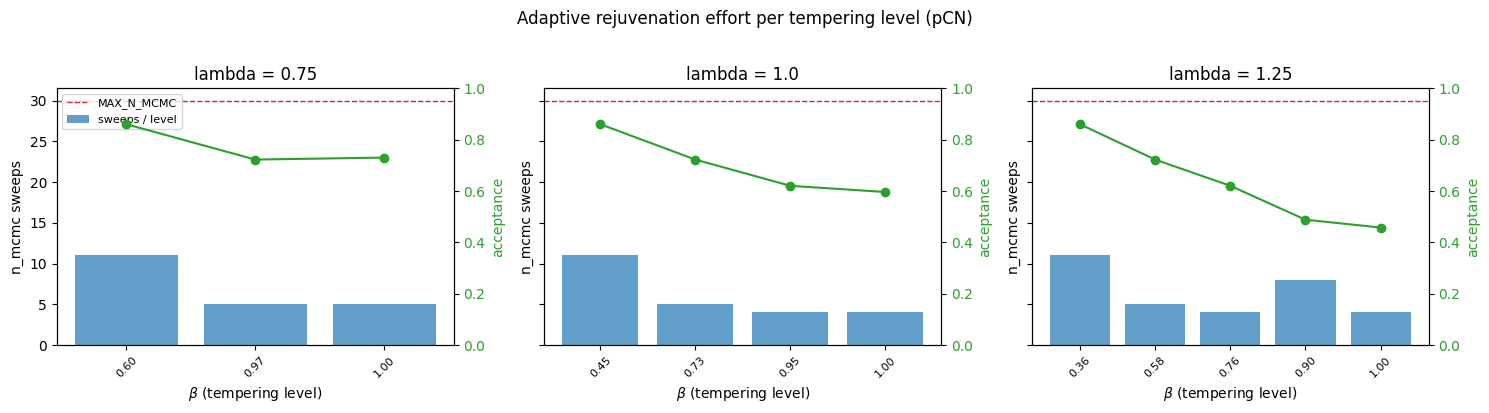

lambda=0.75: adaptive total sweeps= 21 (profile [11, 5, 5]) vs fixed  18
lambda=1.0: adaptive total sweeps= 24 (profile [11, 5, 4, 4]) vs fixed  24
lambda=1.25: adaptive total sweeps= 32 (profile [11, 5, 4, 8, 4]) vs fixed  36


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(LAMBDAS), figsize=(5.0 * len(LAMBDAS), 4.0), sharey=True)
for ax, lam in zip(axes, LAMBDAS):
    res = runs[(lam, "adaptive")]
    betas = res.betas
    x = range(len(betas))
    ax.bar(x, res.n_mcmc_history, color="tab:blue", alpha=0.7, label="sweeps / level")
    ax.axhline(MAX_N_MCMC, ls="--", color="tab:red", lw=1, label="MAX_N_MCMC")
    ax.set_xticks(list(x)); ax.set_xticklabels([f"{b:.2f}" for b in betas], rotation=45, fontsize=8)
    ax.set_xlabel(r"$\beta$ (tempering level)"); ax.set_title(f"lambda = {lam}")
    ax.set_ylabel("n_mcmc sweeps")
    ax2 = ax.twinx()
    ax2.plot(x, res.acc_history, "o-", color="tab:green", label="mean acc")
    ax2.set_ylim(0, 1); ax2.set_ylabel("acceptance", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Adaptive rejuvenation effort per tempering level (pCN)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

for lam in LAMBDAS:
    a = runs[(lam, "adaptive")]; f = runs[(lam, "fixed")]
    print(f"lambda={lam}: adaptive total sweeps={sum(a.n_mcmc_history):3d} (profile {a.n_mcmc_history}) "
          f"vs fixed {sum(f.n_mcmc_history):3d}")

## 3. The `decorrelation` metric behaves — and differs by kernel

The stopping signal is `kernel.decorrelation(state, baseline)` $\in [0, 1]$ (1 = still fully correlated
with the post-resample state, 0 = mixed). We snapshot a baseline, then apply sweeps at a fixed
$(\beta{=}1, \lambda)$ and watch it decay past the default `decorr_threshold = 0.2`:

- **pCN** decays *gradually* — local latent-$z$ moves accumulate. The metric is a **dimension-robust**
  normalized ESJD, $1 - E\lVert z_t - z_0\rVert^2 / (E\lVert z_0\rVert^2 + E\lVert z_t\rVert^2)$, which
  $\to 0$ at independence in *any* dimension (so one threshold transfers from this 2D toy to pixel/latent
  image space, where a raw $\lvert\cos\rvert$ would floor at a $d$-dependent value).
- **Independence** decays *fast* — one accepted global $x'\sim p$ fully replaces a particle, so the
  "still-at-parent fraction" drops as soon as each duplicate accepts once.

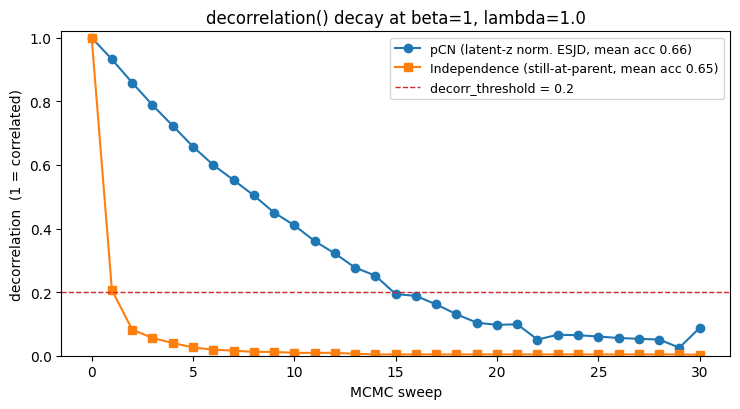

sweeps to cross 0.2:  pCN=15  Independence=2  (None = never within MAX_N_MCMC)


In [4]:
lam_demo, K, cpu = 1.0, MAX_N_MCMC, torch.device("cpu")
DECORR_THRESHOLD = RejuvenationStop().decorr_threshold

def decorr_curve(kernel, seed=0):
    gen = torch.Generator().manual_seed(seed)
    st = kernel.init(1000, reward, generator=gen, device=cpu, dtype=dtype)
    base = kernel.snapshot_baseline(st)
    curve = [kernel.decorrelation(st, base)]
    accs = []
    for _ in range(K):
        accs.append(kernel.step(st, beta=1.0, lam=lam_demo, f=reward, generator=gen))
        curve.append(kernel.decorrelation(st, base))
    return curve, accs

pcn_decorr, pcn_acc = decorr_curve(PCNKernel(G, DDIM, s0=0.4))
ind_decorr, ind_acc = decorr_curve(IndependenceKernel(p))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(range(K + 1), pcn_decorr, "o-", label=f"pCN (latent-z norm. ESJD, mean acc {sum(pcn_acc)/K:.2f})")
ax.plot(range(K + 1), ind_decorr, "s-", label=f"Independence (still-at-parent, mean acc {sum(ind_acc)/K:.2f})")
ax.axhline(DECORR_THRESHOLD, ls="--", color="tab:red", lw=1, label=f"decorr_threshold = {DECORR_THRESHOLD}")
ax.set_xlabel("MCMC sweep"); ax.set_ylabel("decorrelation  (1 = correlated)")
ax.set_title(f"decorrelation() decay at beta=1, lambda={lam_demo}"); ax.set_ylim(0, 1.02); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

def first_below(curve, thr):
    return next((i for i, v in enumerate(curve) if v < thr), None)
print(f"sweeps to cross {DECORR_THRESHOLD}:  pCN={first_below(pcn_decorr, DECORR_THRESHOLD)}  "
      f"Independence={first_below(ind_decorr, DECORR_THRESHOLD)}  (None = never within MAX_N_MCMC)")

## 4. The `decorr_threshold` knob — sweeps vs. mixing

pCN decorrelates slowly in latent space under a strong off-manifold tilt, so a strict threshold makes
levels run to `MAX_N_MCMC`. For expensive `G(z)` (images), `decorr_threshold` is the main lever to trade
sweep budget against mixing. We sweep it on the hard $\lambda = 1.25$ target and read off total sweeps,
recovered $E_q[f_2]$, and particle uniqueness. Pass it via `RejuvenationStop`. The `stop_reason_history`
column shows how loosening the threshold shifts stops from `plateau` toward `decorr` (and away from the
`cap`).

In [5]:
LAM_HARD = 1.25
efg_hard = grid_Ef(LAM_HARD)
print(f"grid E_q[f2] at lambda={LAM_HARD}: {efg_hard:.2f}\n")
print(f"{'decorr_thr':>10} {'levels':>6} {'sweeps':>6} {'E[f2]':>7} {'%grid':>6} {'uniq':>8} {'sec':>5}   profile / stop reasons")
for thr in [0.1, 0.2, 0.4, 0.6]:
    stop = RejuvenationStop(decorr_threshold=thr)
    t = time.time()
    res = smc_sample(reward, lam=LAM_HARD, n_particles=N, kernel=PCNKernel(G, DDIM),
                     n_mcmc=None, stop=stop, ess_target=ESS_TARGET, final_resample=True, seed=0)
    ef = float(reward(res.X).mean()); uniq = int(res.X.unique(dim=0).shape[0])
    print(f"{thr:10.2f} {len(res.betas):6d} {sum(res.n_mcmc_history):6d} {ef:7.2f} "
          f"{ef/efg_hard:6.0%} {uniq:4d}/{N} {time.time()-t:5.0f}   {res.n_mcmc_history}  {res.stop_reason_history}")

grid E_q[f2] at lambda=1.25: 66.11

decorr_thr levels sweeps   E[f2]  %grid     uniq   sec   profile / stop reasons


      0.10      6     36    3.48     5%  540/800    25   [12, 8, 4, 4, 4, 4]  ['decorr', 'decorr', 'plateau', 'plateau', 'plateau', 'plateau']


      0.20      5     32    2.99     5%  619/800    24   [11, 5, 4, 8, 4]  ['decorr', 'decorr', 'plateau', 'plateau', 'plateau']


      0.40      5     32    2.99     5%  627/800    22   [8, 5, 5, 8, 6]  ['decorr', 'decorr', 'decorr', 'decorr', 'plateau']


      0.60      6     27    4.10     6%  508/800    18   [6, 4, 4, 4, 4, 5]  ['decorr', 'decorr', 'decorr', 'decorr', 'plateau', 'decorr']


## Takeaways

- **No `n_mcmc` to guess.** `smc_sample(n_mcmc=None)` reaches quality (`% of grid`, ESS, uniqueness)
  comparable to the hand-tuned fixed run, while spending sweeps adaptively per level.
- **Effort follows difficulty.** The `n_mcmc_history` profile stays near `min_n_mcmc` on easy levels and
  climbs toward `MAX_N_MCMC` exactly where pCN acceptance sags (the hard off-manifold levels).
- **The metric is honest and cheap.** `decorrelation` decays as designed — gradually for pCN's local
  latent moves, sharply for Independence's global jumps — and is measured in the scalar `f` / low-dim
  latent `z`, never pixel space, so it scales to images.
- **One knob for cost.** When `G(z)` is expensive, `RejuvenationStop(decorr_threshold=…, max_n_mcmc=…)`
  trades sweep budget against mixing; use `n_mcmc_history` + `acc_history` to see where the budget goes.